# Near Duplicate Analysis

This notebook analyzes near-duplicate articles in the cleaned dataset to understand:

1. **Similarity Distribution**: How similar are articles to each other?
2. **Near-Duplicate Detection**: Find article pairs that are highly similar but not exact duplicates
3. **Label Consistency**: Do near-duplicates have consistent labels?
4. **Potential Data Leakage**: Are near-duplicates split across train/test sets?

**Methods Used:**
- TF-IDF + Cosine Similarity
- MinHash/LSH (Locality Sensitive Hashing) for scalable duplicate detection
- N-gram Jaccard Similarity


In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings

# For similarity computation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# For MinHash/LSH
from datasketch import MinHash, MinHashLSH

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

warnings.filterwarnings('ignore')

print("✓ Imports successful")


✓ Imports successful


## 1. Load Data

Load the cleaned dataset and explore its structure.


In [3]:
# Load cleaned dataset
data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"
df = pd.read_csv(data_path)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print(f"\nLabel distribution:")
print(df['label'].value_counts())

print(f"\nSample articles:")
display(df.head(3))

# Check for any remaining exact duplicates
exact_dupes = df.duplicated(subset=['text'], keep=False).sum()
print(f"\nExact duplicates in 'text' column: {exact_dupes}")


DATASET OVERVIEW

Shape: (44439, 4)
Columns: ['id', 'title', 'text', 'label']

Label distribution:
label
0    29561
1    14878
Name: count, dtype: int64

Sample articles:


,id,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,NaN,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last n...",1



Exact duplicates in 'text' column: 2


## 2. Near-Duplicate Detection with MinHash/LSH

MinHash with Locality Sensitive Hashing (LSH) is a scalable approach for finding similar documents. It approximates Jaccard similarity efficiently.

**Parameters:**
- `num_perm`: Number of permutations (higher = more accurate, slower)
- `threshold`: Jaccard similarity threshold for considering documents as near-duplicates


In [4]:
def get_shingles(text, k=3):
    """Convert text to k-shingles (character n-grams)."""
    text = str(text).lower()
    return set(text[i:i+k] for i in range(len(text) - k + 1))

def get_word_shingles(text, k=2):
    """Convert text to word k-shingles (word n-grams)."""
    words = str(text).lower().split()
    if len(words) < k:
        return set([' '.join(words)])
    return set(' '.join(words[i:i+k]) for i in range(len(words) - k + 1))

def create_minhash(shingles, num_perm=128):
    """Create MinHash signature from shingles."""
    m = MinHash(num_perm=num_perm)
    for s in shingles:
        m.update(s.encode('utf-8'))
    return m

print("✓ Helper functions defined")


✓ Helper functions defined


In [5]:
print("=" * 60)
print("BUILDING MINHASH INDEX")
print("=" * 60)

# Configuration
NUM_PERM = 128  # Number of permutations for MinHash
THRESHOLD = 0.5  # Jaccard similarity threshold

print(f"\nConfiguration:")
print(f"  Num permutations: {NUM_PERM}")
print(f"  Similarity threshold: {THRESHOLD}")

# Create MinHash LSH index
lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)

# Store MinHash signatures
minhashes = {}

print(f"\nProcessing {len(df)} documents...")

# Create MinHash for each document
for idx, row in df.iterrows():
    text = row['text']
    shingles = get_word_shingles(text, k=2)
    minhash = create_minhash(shingles, num_perm=NUM_PERM)
    minhashes[idx] = minhash
    lsh.insert(str(idx), minhash)
    
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx + 1} documents...")

print(f"\n✓ MinHash index built for {len(df)} documents")


BUILDING MINHASH INDEX

Configuration:
  Num permutations: 128
  Similarity threshold: 0.5

Processing 44439 documents...
  Processed 10000 documents...
  Processed 20000 documents...
  Processed 30000 documents...
  Processed 40000 documents...

✓ MinHash index built for 44439 documents


In [7]:
print("=" * 60)
print("FINDING NEAR-DUPLICATE PAIRS")
print("=" * 60)

# Find all near-duplicate pairs
near_duplicate_pairs = []
seen_pairs = set()

for idx in minhashes:
    # Query LSH for similar documents
    results = lsh.query(minhashes[idx])
    
    for result in results:
        other_idx = int(result)
        if other_idx != idx:
            # Create ordered pair to avoid duplicates
            pair = tuple(sorted([idx, other_idx]))
            if pair not in seen_pairs:
                seen_pairs.add(pair)
                # Calculate actual Jaccard similarity
                jaccard = minhashes[idx].jaccard(minhashes[other_idx])
                near_duplicate_pairs.append({
                    'idx1': pair[0],
                    'idx2': pair[1],
                    'jaccard_similarity': jaccard,
                    'label1': df.loc[pair[0], 'label'],
                    'label2': df.loc[pair[1], 'label']
                })

pairs_df = pd.DataFrame(near_duplicate_pairs)
print(f"\nFound {len(pairs_df)} near-duplicate pairs (threshold ≥ {THRESHOLD})")

if len(pairs_df) > 0:
    print(f"\nSimilarity statistics:")
    print(pairs_df['jaccard_similarity'].describe())


FINDING NEAR-DUPLICATE PAIRS

Found 2542 near-duplicate pairs (threshold ≥ 0.5)

Similarity statistics:
count    2542.000000
mean        0.742052
std         0.195592
min         0.039062
25%         0.601562
50%         0.781250
75%         0.906250
max         1.000000
Name: jaccard_similarity, dtype: float64


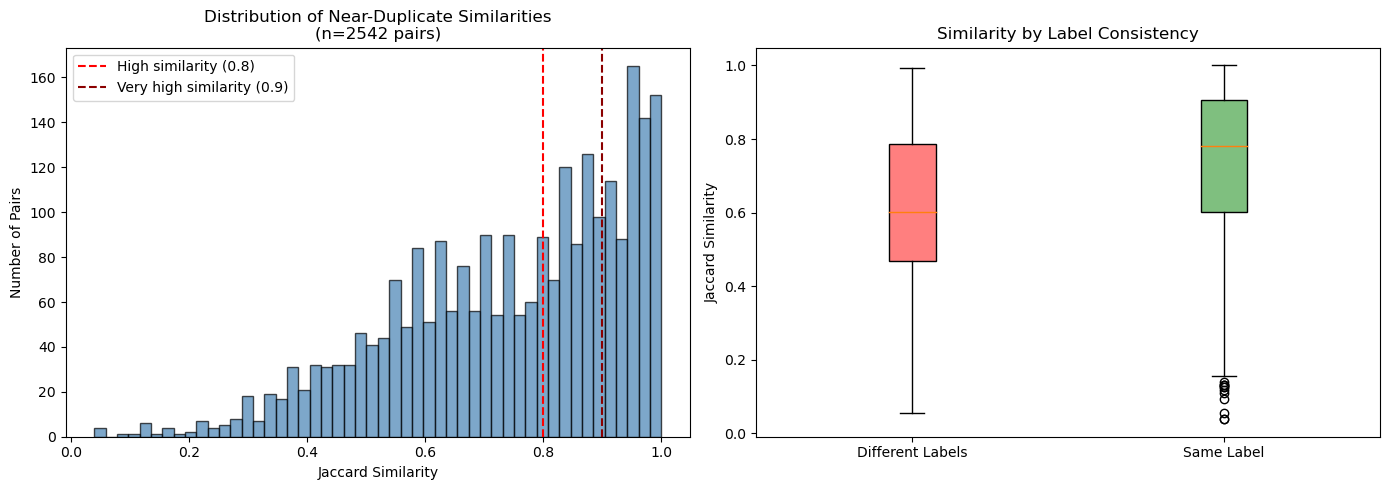

In [8]:
# Visualize similarity distribution
if len(pairs_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Similarity distribution
    ax1 = axes[0]
    ax1.hist(pairs_df['jaccard_similarity'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Jaccard Similarity')
    ax1.set_ylabel('Number of Pairs')
    ax1.set_title(f'Distribution of Near-Duplicate Similarities\n(n={len(pairs_df)} pairs)')
    ax1.axvline(x=0.8, color='red', linestyle='--', label='High similarity (0.8)')
    ax1.axvline(x=0.9, color='darkred', linestyle='--', label='Very high similarity (0.9)')
    ax1.legend()
    
    # Similarity by label consistency
    ax2 = axes[1]
    pairs_df['label_match'] = pairs_df['label1'] == pairs_df['label2']
    label_groups = pairs_df.groupby('label_match')['jaccard_similarity'].apply(list)
    
    data_to_plot = []
    labels_to_plot = []
    if False in label_groups.index:
        data_to_plot.append(label_groups[False])
        labels_to_plot.append('Different Labels')
    if True in label_groups.index:
        data_to_plot.append(label_groups[True])
        labels_to_plot.append('Same Label')
    
    bp = ax2.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
    colors = ['#ff7f7f', '#7fbf7f']
    for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
        patch.set_facecolor(color)
    ax2.set_ylabel('Jaccard Similarity')
    ax2.set_title('Similarity by Label Consistency')
    
    plt.tight_layout()
    plt.show()
else:
    print("No near-duplicate pairs found at threshold", THRESHOLD)


## 3. Label Consistency Analysis

Check if near-duplicate articles have consistent labels. Inconsistent labels could indicate labeling errors or subtle differences that affect classification.


In [9]:
if len(pairs_df) > 0:
    print("=" * 60)
    print("LABEL CONSISTENCY ANALYSIS")
    print("=" * 60)
    
    # Overall label consistency
    pairs_df['label_match'] = pairs_df['label1'] == pairs_df['label2']
    consistency_counts = pairs_df['label_match'].value_counts()
    
    print(f"\nLabel Consistency:")
    print(f"  Same label: {consistency_counts.get(True, 0)} pairs ({100*consistency_counts.get(True, 0)/len(pairs_df):.1f}%)")
    print(f"  Different label: {consistency_counts.get(False, 0)} pairs ({100*consistency_counts.get(False, 0)/len(pairs_df):.1f}%)")
    
    # Analyze by similarity threshold
    print(f"\nInconsistent pairs by similarity level:")
    for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
        subset = pairs_df[pairs_df['jaccard_similarity'] >= thresh]
        if len(subset) > 0:
            inconsistent = (~subset['label_match']).sum()
            print(f"  Similarity ≥ {thresh}: {inconsistent}/{len(subset)} inconsistent ({100*inconsistent/len(subset):.1f}%)")
    
    # Show examples of inconsistent pairs with high similarity
    inconsistent_pairs = pairs_df[(~pairs_df['label_match']) & (pairs_df['jaccard_similarity'] >= 0.7)]
    inconsistent_pairs = inconsistent_pairs.sort_values('jaccard_similarity', ascending=False)
    
    print(f"\nTop inconsistent pairs (different labels, high similarity):")
    print(f"Found {len(inconsistent_pairs)} pairs with similarity ≥ 0.7 and different labels")
else:
    print("No pairs to analyze")


LABEL CONSISTENCY ANALYSIS

Label Consistency:
  Same label: 2515 pairs (98.9%)
  Different label: 27 pairs (1.1%)

Inconsistent pairs by similarity level:
  Similarity ≥ 0.5: 19/2234 inconsistent (0.9%)
  Similarity ≥ 0.6: 14/1924 inconsistent (0.7%)
  Similarity ≥ 0.7: 10/1569 inconsistent (0.6%)
  Similarity ≥ 0.8: 7/1201 inconsistent (0.6%)
  Similarity ≥ 0.9: 2/661 inconsistent (0.3%)

Top inconsistent pairs (different labels, high similarity):
Found 10 pairs with similarity ≥ 0.7 and different labels


In [10]:
# Show examples of inconsistent high-similarity pairs
if len(pairs_df) > 0 and len(inconsistent_pairs) > 0:
    print("=" * 60)
    print("EXAMPLE INCONSISTENT PAIRS")
    print("=" * 60)
    
    for i, (_, row) in enumerate(inconsistent_pairs.head(3).iterrows()):
        print(f"\n--- Pair {i+1} (Jaccard: {row['jaccard_similarity']:.3f}) ---")
        
        idx1, idx2 = int(row['idx1']), int(row['idx2'])
        text1 = df.loc[idx1, 'text'][:500] + "..." if len(str(df.loc[idx1, 'text'])) > 500 else df.loc[idx1, 'text']
        text2 = df.loc[idx2, 'text'][:500] + "..." if len(str(df.loc[idx2, 'text'])) > 500 else df.loc[idx2, 'text']
        
        print(f"\nArticle {idx1} (Label: {row['label1']}):")
        print(f"  {text1}")
        
        print(f"\nArticle {idx2} (Label: {row['label2']}):")
        print(f"  {text2}")
else:
    print("No inconsistent high-similarity pairs found")


EXAMPLE INCONSISTENT PAIRS

--- Pair 1 (Jaccard: 0.992) ---

Article 28171 (Label: 0):
  On a rooftop overlooking the walls of Jerusalem’s Old City, around 200 American-Israeli fans of Donald Trump gathered to proclaim their support for the Republican candidate, convinced he will be Israel’s best friend if elected. Wearing “Make America Great Again” baseball caps, the small crowd, ranging from Holocaust survivors in their 80s to grinning teenagers in Trump t-shirts, said they didn’t care about the sexual assault allegations against the candidate or the online anti-Semitism of some o...

Article 33209 (Label: 1):
  Reuters 
On a rooftop overlooking the walls of Jerusalem’s Old City, around 200 American-Israeli fans of Donald Trump gathered to proclaim their support for the Republican candidate, convinced he will be Israel’s best friend if elected. 
Wearing “Make America Great Again” baseball caps, the small crowd, ranging from Holocaust survivors in their 80s to grinning teenagers in Tr

## 4. Train/Test Leakage Analysis

Check if near-duplicate articles are split across train and test sets, which could cause data leakage and inflated performance metrics.


In [11]:
# Load train/test splits
train_path = project_root / "data" / "processed" / "train.csv"
test_path = project_root / "data" / "processed" / "test.csv"

try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    # Get indices
    train_indices = set(train_df.index)
    test_indices = set(test_df.index)
    
    print("=" * 60)
    print("TRAIN/TEST SPLIT INFO")
    print("=" * 60)
    print(f"\nTrain samples: {len(train_df)}")
    print(f"Test samples: {len(test_df)}")
    
    # Note: The indices in train/test CSV may not match the cleaned_dataset indices
    # We need to match by text content
    train_texts = set(train_df['text'].values)
    test_texts = set(test_df['text'].values)
    
    # Map cleaned dataset indices to train/test
    df['split'] = df['text'].apply(lambda x: 'train' if x in train_texts else ('test' if x in test_texts else 'unknown'))
    
    print(f"\nSplit distribution in cleaned dataset:")
    print(df['split'].value_counts())
    
except FileNotFoundError:
    print("Train/test split files not found. Run the split first.")
    df['split'] = 'unknown'


TRAIN/TEST SPLIT INFO

Train samples: 35551
Test samples: 8888

Split distribution in cleaned dataset:
split
train    35551
test      8888
Name: count, dtype: int64


In [12]:
if len(pairs_df) > 0 and 'split' in df.columns:
    print("=" * 60)
    print("CROSS-SPLIT LEAKAGE ANALYSIS")
    print("=" * 60)
    
    # Add split info to pairs
    pairs_df['split1'] = pairs_df['idx1'].apply(lambda x: df.loc[x, 'split'] if x in df.index else 'unknown')
    pairs_df['split2'] = pairs_df['idx2'].apply(lambda x: df.loc[x, 'split'] if x in df.index else 'unknown')
    
    # Identify cross-split pairs (potential leakage)
    pairs_df['cross_split'] = (pairs_df['split1'] != pairs_df['split2']) & \
                               (pairs_df['split1'] != 'unknown') & \
                               (pairs_df['split2'] != 'unknown')
    
    cross_split_pairs = pairs_df[pairs_df['cross_split']]
    
    print(f"\nCross-split near-duplicate pairs (POTENTIAL LEAKAGE):")
    print(f"  Total cross-split pairs: {len(cross_split_pairs)}")
    
    if len(cross_split_pairs) > 0:
        print(f"\n  By similarity threshold:")
        for thresh in [0.5, 0.6, 0.7, 0.8, 0.9]:
            count = (cross_split_pairs['jaccard_similarity'] >= thresh).sum()
            print(f"    Similarity ≥ {thresh}: {count} pairs")
        
        print(f"\n  Similarity statistics for cross-split pairs:")
        print(cross_split_pairs['jaccard_similarity'].describe())
    else:
        print("  ✓ No cross-split near-duplicates found!")
else:
    print("Cannot analyze leakage - missing pairs or split info")


CROSS-SPLIT LEAKAGE ANALYSIS

Cross-split near-duplicate pairs (POTENTIAL LEAKAGE):
  Total cross-split pairs: 770

  By similarity threshold:
    Similarity ≥ 0.5: 704 pairs
    Similarity ≥ 0.6: 610 pairs
    Similarity ≥ 0.7: 513 pairs
    Similarity ≥ 0.8: 396 pairs
    Similarity ≥ 0.9: 231 pairs

  Similarity statistics for cross-split pairs:
count    770.000000
mean       0.765057
std        0.183085
min        0.140625
25%        0.632812
50%        0.804688
75%        0.921875
max        1.000000
Name: jaccard_similarity, dtype: float64


## 5. TF-IDF Cosine Similarity Analysis

Use TF-IDF vectors and cosine similarity for a complementary view of near-duplicates. This method captures semantic similarity better than Jaccard on shingles.


In [13]:
print("=" * 60)
print("TF-IDF COSINE SIMILARITY ANALYSIS")
print("=" * 60)

# Create TF-IDF vectors
print("\nCreating TF-IDF vectors...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['text'].fillna(''))

print(f"  TF-IDF matrix shape: {tfidf_matrix.shape}")

# Sample analysis: compute pairwise similarities on a sample
SAMPLE_SIZE = 5000
if len(df) > SAMPLE_SIZE:
    print(f"\nSampling {SAMPLE_SIZE} documents for pairwise comparison...")
    sample_indices = np.random.choice(len(df), SAMPLE_SIZE, replace=False)
    sample_matrix = tfidf_matrix[sample_indices]
else:
    sample_indices = np.arange(len(df))
    sample_matrix = tfidf_matrix

print("Computing pairwise cosine similarities...")
sim_matrix = cosine_similarity(sample_matrix)

# Get upper triangle (excluding diagonal)
upper_tri = np.triu_indices_from(sim_matrix, k=1)
similarities = sim_matrix[upper_tri]

print(f"\nCosine similarity statistics ({len(similarities)} pairs):")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Median: {np.median(similarities):.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Std: {similarities.std():.4f}")


TF-IDF COSINE SIMILARITY ANALYSIS

Creating TF-IDF vectors...
  TF-IDF matrix shape: (44439, 5000)

Sampling 5000 documents for pairwise comparison...
Computing pairwise cosine similarities...

Cosine similarity statistics (12497500 pairs):
  Mean: 0.0384
  Median: 0.0288
  Max: 1.0000
  Std: 0.0402


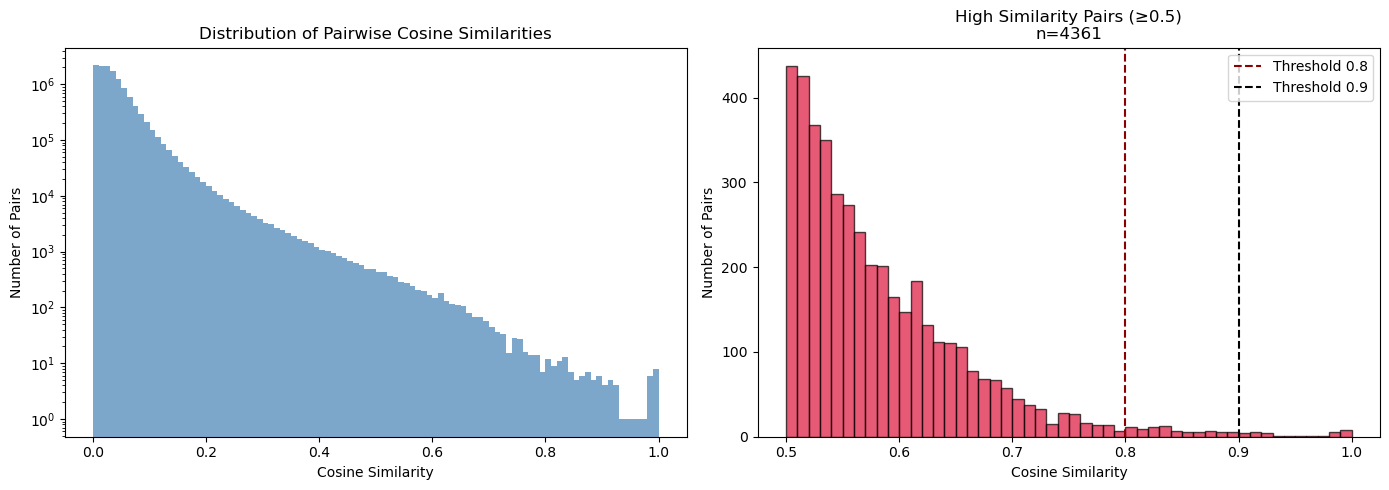


Pairs by cosine similarity threshold:
  ≥ 0.5: 4361 pairs (0.0349%)
  ≥ 0.6: 1411 pairs (0.0113%)
  ≥ 0.7: 348 pairs (0.0028%)
  ≥ 0.8: 113 pairs (0.0009%)
  ≥ 0.9: 32 pairs (0.0003%)
  ≥ 0.95: 17 pairs (0.0001%)


In [14]:
# Visualize similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
ax1 = axes[0]
ax1.hist(similarities, bins=100, color='steelblue', edgecolor='none', alpha=0.7)
ax1.set_xlabel('Cosine Similarity')
ax1.set_ylabel('Number of Pairs')
ax1.set_title('Distribution of Pairwise Cosine Similarities')
ax1.set_yscale('log')

# High similarity tail
ax2 = axes[1]
high_sim = similarities[similarities >= 0.5]
ax2.hist(high_sim, bins=50, color='crimson', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Number of Pairs')
ax2.set_title(f'High Similarity Pairs (≥0.5)\nn={len(high_sim)}')
ax2.axvline(x=0.8, color='darkred', linestyle='--', label='Threshold 0.8')
ax2.axvline(x=0.9, color='black', linestyle='--', label='Threshold 0.9')
ax2.legend()

plt.tight_layout()
plt.show()

# Count pairs by threshold
print("\nPairs by cosine similarity threshold:")
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    count = (similarities >= thresh).sum()
    print(f"  ≥ {thresh}: {count} pairs ({100*count/len(similarities):.4f}%)")


## 6. Summary and Recommendations


In [15]:
print("=" * 60)
print("NEAR-DUPLICATE ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n** Dataset **")
print(f"  Total articles: {len(df)}")
print(f"  Real (0): {(df['label'] == 0).sum()}")
print(f"  Fake (1): {(df['label'] == 1).sum()}")

if len(pairs_df) > 0:
    print(f"\n** MinHash/LSH Analysis (Jaccard threshold ≥ {THRESHOLD}) **")
    print(f"  Near-duplicate pairs found: {len(pairs_df)}")
    print(f"  Mean Jaccard similarity: {pairs_df['jaccard_similarity'].mean():.3f}")
    
    if 'label_match' in pairs_df.columns:
        inconsistent = (~pairs_df['label_match']).sum()
        print(f"  Pairs with inconsistent labels: {inconsistent} ({100*inconsistent/len(pairs_df):.1f}%)")
    
    if 'cross_split' in pairs_df.columns:
        cross_split = pairs_df['cross_split'].sum()
        print(f"  Cross-split pairs (potential leakage): {cross_split}")

print(f"\n** TF-IDF Cosine Similarity (sampled {len(sample_indices)} docs) **")
print(f"  High similarity pairs (≥0.8): {(similarities >= 0.8).sum()}")
print(f"  Very high similarity pairs (≥0.9): {(similarities >= 0.9).sum()}")

print(f"\n** Recommendations **")
if len(pairs_df) > 0 and 'cross_split' in pairs_df.columns and pairs_df['cross_split'].sum() > 0:
    print("  ⚠ Cross-split near-duplicates detected - consider deduplication before splitting")
if len(pairs_df) > 0 and 'label_match' in pairs_df.columns and (~pairs_df['label_match']).sum() > 0:
    print("  ⚠ Inconsistent labels found in near-duplicates - review labeling quality")
if (similarities >= 0.9).sum() > 0:
    print("  ⚠ Very high similarity pairs exist - may need stricter deduplication")


NEAR-DUPLICATE ANALYSIS SUMMARY

** Dataset **
  Total articles: 44439
  Real (0): 29561
  Fake (1): 14878

** MinHash/LSH Analysis (Jaccard threshold ≥ 0.5) **
  Near-duplicate pairs found: 2542
  Mean Jaccard similarity: 0.742
  Pairs with inconsistent labels: 27 (1.1%)
  Cross-split pairs (potential leakage): 770

** TF-IDF Cosine Similarity (sampled 5000 docs) **
  High similarity pairs (≥0.8): 113
  Very high similarity pairs (≥0.9): 32

** Recommendations **
  ⚠ Cross-split near-duplicates detected - consider deduplication before splitting
  ⚠ Inconsistent labels found in near-duplicates - review labeling quality
  ⚠ Very high similarity pairs exist - may need stricter deduplication


In [16]:
# Save near-duplicate pairs for further analysis
if len(pairs_df) > 0:
    output_path = project_root / "data" / "processed" / "near_duplicate_pairs.csv"
    pairs_df.to_csv(output_path, index=False)
    print(f"✓ Near-duplicate pairs saved to: {output_path}")
    
    # Save high-similarity pairs separately
    high_sim_pairs = pairs_df[pairs_df['jaccard_similarity'] >= 0.8]
    if len(high_sim_pairs) > 0:
        high_sim_path = project_root / "data" / "processed" / "high_similarity_pairs.csv"
        high_sim_pairs.to_csv(high_sim_path, index=False)
        print(f"✓ High-similarity pairs (≥0.8) saved to: {high_sim_path}")


✓ Near-duplicate pairs saved to: /Users/alanye/Fake-News-Group-3/data/processed/near_duplicate_pairs.csv
✓ High-similarity pairs (≥0.8) saved to: /Users/alanye/Fake-News-Group-3/data/processed/high_similarity_pairs.csv
